# GLM Power Creep Analysis

This notebook rebuilds the attack-focused GLM study using the curated dataset under `data/data_clean.csv`. The layout mirrors the lightweight notebooks in `analysis/`, while the modeling choices follow `tychtjan_analysis/GLM_context.md` and the exploratory work in `tychtjan_analysis/glm_analysis.ipynb`.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:.2f}".format

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "data_clean.csv"
if not DATA_PATH.exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_PATH = PROJECT_ROOT / "data" / "data_clean.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot locate data_clean.csv from {PROJECT_ROOT}. Check the repo layout."
    )

### Load and preview the cleaned Pokémon dataset

In [3]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(raw_df):,} | Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 1,024 | Columns: 41


,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,against_fairy,votes_first,votes_top_6,num_abilities,evo_length,has_mega_evolution,has_gigantamax,rarity,class_primary,class_secondary
0,1.00,Bulbasaur,88.14,11.86,0.70,6.90,45.00,5120.00,45.00,49.00,...,0.50,57.00,147.00,2.00,5.00,0.00,0.00,0.00,0,0
1,1.00,Ivysaur,88.14,11.86,1.00,13.00,45.00,5120.00,60.00,62.00,...,0.50,2.00,25.00,2.00,5.00,0.00,0.00,0.00,0,0
2,1.00,Venusaur,88.14,11.86,2.00,100.00,45.00,5120.00,80.00,82.00,...,0.50,9.00,61.00,2.00,5.00,1.00,1.00,0.00,0,0
3,1.00,Charmander,88.14,11.86,0.60,8.50,45.00,5120.00,39.00,52.00,...,0.50,12.00,38.00,2.00,5.00,0.00,0.00,0.00,1,1
4,1.00,Charmeleon,88.14,11.86,1.10,19.00,45.00,5120.00,58.00,64.00,...,0.50,3.00,8.00,2.00,5.00,0.00,0.00,0.00,1,1


### Feature engineering pipeline

We reproduce the engineered fields described in `GLM_context.md`: composite stats, mechanic complexity flags, resistance PCA, and lightly transformed skewed columns. Type/id columns are mapped back to readable labels so categorical contrasts are easy to interpret.

In [4]:
STAT_COLUMNS = ["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]
RESISTANCE_COLS = [col for col in raw_df.columns if col.startswith("against_")]
TYPE_ORDER = [
    "grass", "fire", "water", "bug", "normal", "poison", "electric", "ground",
    "fairy", "fighting", "psychic", "rock", "ghost", "ice", "dragon", "dark",
    "steel", "flying"
]
RARITY_LABELS = {0: "normal", 1: "sublegendary", 2: "legendary", 3: "mythical"}


def engineer_features(df: pd.DataFrame):
    out = df.copy().dropna(subset=["attack"]).reset_index(drop=True)
    out["gen"] = out["gen"].astype(int)
    # Composite offensive/defensive stats
    out["total_offense"] = out["attack"] + out["sp_attack"]
    out["total_defense"] = out["defense"] + out["sp_defense"]
    out["overall_stat_sum"] = out[STAT_COLUMNS].sum(axis=1)
    out["offense_ratio"] = out["total_offense"] / out["total_defense"].replace(0, np.nan)
    out["aggression_index"] = out["attack"] / out["overall_stat_sum"]
    out["offense_share"] = out["total_offense"] / out["overall_stat_sum"]
    # Skew-reducing transforms
    for col in ["weight_kg", "base_egg_steps", "capture_rate"]:
        out[f"log_{col}"] = np.log1p(out[col].clip(lower=0))
    for col in ["votes_first", "votes_top_6"]:
        out[f"sqrt_{col}"] = np.sqrt(out[col].clip(lower=0))
    # Mechanics flags
    out["mechanic_stack"] = out["has_mega_evolution"].fillna(0) + out["has_gigantamax"].fillna(0)
    out["long_evo_chain"] = (out["evo_length"].fillna(0) >= 3).astype(int)
    out["mechanic_complexity"] = out["mechanic_stack"] + out["long_evo_chain"]
    # Type / rarity labels for readable contrasts
    type_map = {idx: name.title() for idx, name in enumerate(TYPE_ORDER)}
    out["primary_type"] = out["class_primary"].map(type_map).fillna("Unknown")
    out["secondary_type"] = out["class_secondary"].map(type_map).fillna("None")
    out["rarity_label"] = out["rarity"].map(RARITY_LABELS).fillna("normal")
    # Resistance PCA (3 components explain ~45% of scaled variance)
    scaler = StandardScaler()
    resistance_scaled = scaler.fit_transform(out[RESISTANCE_COLS])
    pca = PCA(n_components=3, random_state=42)
    resistance_pcs = pca.fit_transform(resistance_scaled)
    for idx in range(3):
        out[f"resistance_pc{idx+1}"] = resistance_pcs[:, idx]
    meta = {
        "resistance_variance_ratio": pca.explained_variance_ratio_.round(4).tolist(),
        "resistance_cols": RESISTANCE_COLS,
    }
    # Clean up inf values produced by zero division
    out = out.replace({np.inf: np.nan, -np.inf: np.nan})
    return out, meta

In [5]:
feature_df, resistance_meta = engineer_features(raw_df)
print("Feature rows:", len(feature_df))
print("Resistance PCA variance explained:", resistance_meta["resistance_variance_ratio"])
feature_df.head(3)

Feature rows: 1024
Resistance PCA variance explained: [0.1992, 0.139, 0.1147]


,gen,english_name,percent_male,percent_female,height_m,weight_kg,capture_rate,base_egg_steps,hp,attack,...,sqrt_votes_top_6,mechanic_stack,long_evo_chain,mechanic_complexity,primary_type,secondary_type,rarity_label,resistance_pc1,resistance_pc2,resistance_pc3
0,1,Bulbasaur,88.14,11.86,0.70,6.90,45.00,5120.00,45.00,49.00,...,12.12,0.00,1,1.00,Grass,Grass,normal,1.82,1.21,-0.56
1,1,Ivysaur,88.14,11.86,1.00,13.00,45.00,5120.00,60.00,62.00,...,5.00,0.00,1,1.00,Grass,Grass,normal,1.82,1.21,-0.56
2,1,Venusaur,88.14,11.86,2.00,100.00,45.00,5120.00,80.00,82.00,...,7.81,2.00,1,3.00,Grass,Grass,normal,1.82,1.21,-0.56


### Correlation diagnostics (Pearson / Spearman / Kendall)

Replicates the multi-metric correlation screen from the legacy SAN playbook to understand how offensive and defensive aggregates move with `attack`.

In [6]:
corr_cols = [
    "attack", "total_offense", "total_defense", "overall_stat_sum",
    "hp", "defense", "sp_attack", "sp_defense", "speed"
]

corr_long = []
for method in ["pearson", "spearman", "kendall"]:
    corr_series = feature_df[corr_cols].corr(method=method)["attack"].drop(labels=["attack"])
    corr_long.append(pd.DataFrame({"metric": corr_series.index, "correlation": corr_series.values, "method": method}))

corr_table = pd.concat(corr_long).pivot(index="metric", columns="method", values="correlation")
print("Correlation vs. attack (sorted by Pearson strength):")
corr_table.sort_values(by="pearson", ascending=False)

Correlation vs. attack (sorted by Pearson strength):


method,kendall,pearson,spearman
metric,,,
total_offense,0.62,0.80,0.80
overall_stat_sum,0.53,0.71,0.71
hp,0.44,0.48,0.59
defense,0.38,0.47,0.53
total_defense,0.33,0.41,0.47
speed,0.25,0.35,0.36
sp_attack,0.21,0.28,0.30
sp_defense,0.21,0.23,0.30


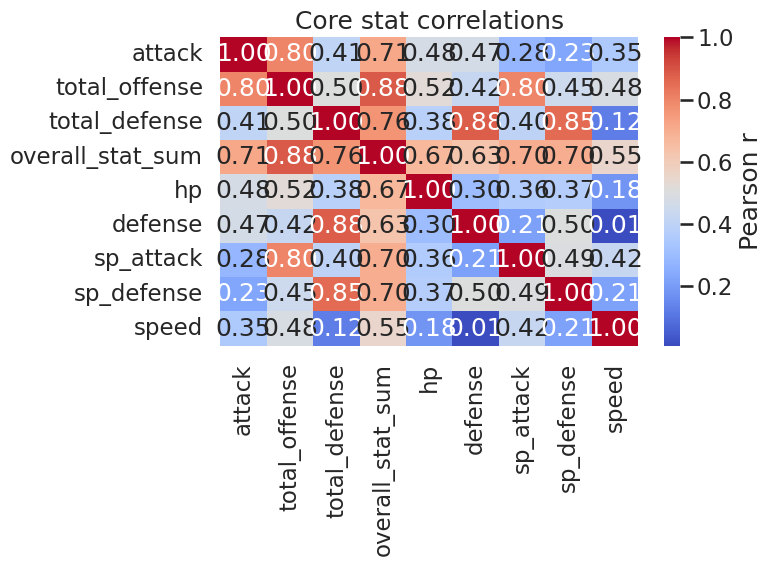

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(feature_df[corr_cols].corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Pearson r"})
plt.title("Core stat correlations")
plt.tight_layout()
plt.show()

### Generational aggregates and mechanic drift

Aggregate means mirror the summary table captured in the GLM context document, letting us verify whether later generations sustain higher offensive stats while mechanic complexity ebbs and flows.

In [8]:
summary_cols = ["attack", "total_offense", "overall_stat_sum", "offense_ratio", "mechanic_complexity"]
gen_summary = feature_df.groupby("gen")[summary_cols].mean().round(2)
gen_summary

,attack,total_offense,overall_stat_sum,offense_ratio,mechanic_complexity
gen,,,,,
1,72.91,140.05,407.64,1.07,1.07
2,68.26,132.76,407.18,1.02,0.87
3,73.11,140.97,403.73,1.13,0.96
4,80.21,153.50,445.76,1.10,0.87
5,81.03,150.28,425.76,1.12,0.84
6,72.50,145.04,429.31,1.00,0.85
7,84.77,159.73,449.41,1.12,0.66
8,82.88,154.18,438.53,1.12,0.91
9,82.42,155.29,457.39,1.08,0.57


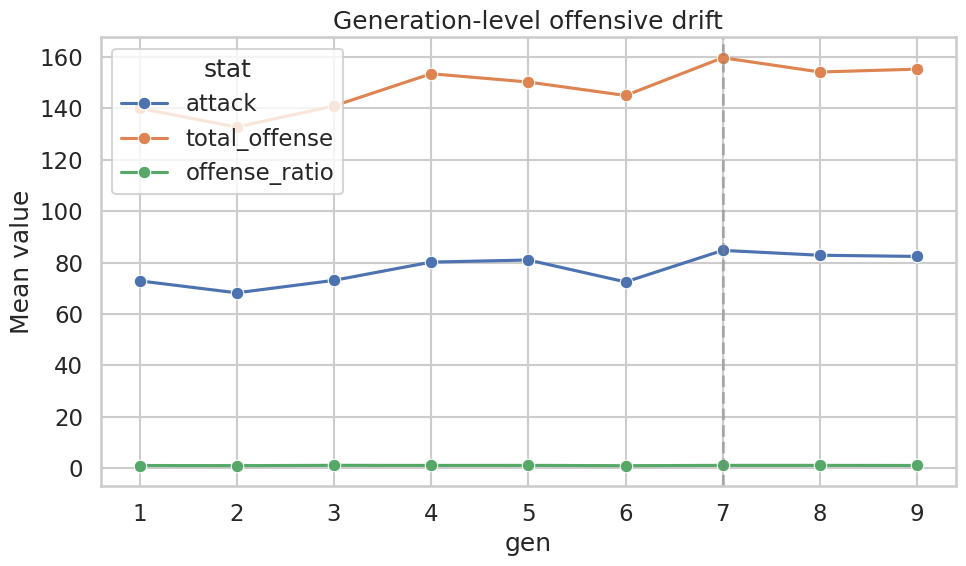

In [9]:
melted = gen_summary.reset_index().melt(id_vars="gen", value_vars=["attack", "total_offense", "offense_ratio"], var_name="stat", value_name="value")
plt.figure(figsize=(10, 6))
sns.lineplot(data=melted, x="gen", y="value", hue="stat", marker="o")
plt.axvline(7, ls="--", color="grey", alpha=0.5)
plt.title("Generation-level offensive drift")
plt.ylabel("Mean value")
plt.tight_layout()
plt.show()

### ElasticNet feature screen

Following the penalized GLM idea in `GLM_context.md`, shrinkage helps surface which engineered predictors retain explanatory power once dummy expansions are included.

In [10]:
enet_features = [
    "total_offense", "total_defense", "overall_stat_sum", "offense_ratio",
    "aggression_index", "offense_share", "hp", "defense", "sp_attack",
    "sp_defense", "speed", "mechanic_complexity", "num_abilities",
    "log_weight_kg", "log_base_egg_steps", "log_capture_rate",
    "sqrt_votes_first", "sqrt_votes_top_6", "resistance_pc1",
    "resistance_pc2", "resistance_pc3", "gen"
]

enet_df = feature_df.dropna(subset=enet_features + ["rarity_label", "primary_type", "secondary_type", "attack"])
X_enet = enet_df[enet_features]
X_enet = pd.get_dummies(
    pd.concat([X_enet, enet_df[["rarity_label", "primary_type", "secondary_type"]]], axis=1),
    columns=["rarity_label", "primary_type", "secondary_type"],
    drop_first=True
)
y_enet = enet_df["attack"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enet)

enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], n_alphas=75, cv=5, random_state=42, max_iter=6000)
enet.fit(X_scaled, y_enet)

coef_series = pd.Series(enet.coef_, index=X_enet.columns)
non_zero = coef_series[coef_series.abs() > 1e-6].sort_values(key=np.abs, ascending=False).head(15)
print(f"Chosen alpha: {enet.alpha_:.3f} | l1_ratio: {enet.l1_ratio_:.2f}")
non_zero.to_frame(name="ElasticNet coef")

Chosen alpha: 0.027 | l1_ratio: 0.90


/home/jenda/Desktop/SAN/pokedex_analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,ElasticNet coef
total_offense,36.04
sp_attack,-22.52
overall_stat_sum,5.02
aggression_index,4.68
sp_defense,-0.42
log_weight_kg,0.20
resistance_pc1,0.11
secondary_type_Dark,-0.10
offense_ratio,-0.10
secondary_type_Fighting,0.08


### Gaussian GLMs (with and without generational/mechanic terms)

We mirror the dual-model comparison from the context doc: first a stat-only baseline, then an augmented model that layers generation, resistance PCs, mechanics, and type controls.

In [11]:
glm_cols = [
    "attack", "total_offense", "total_defense", "overall_stat_sum", "offense_ratio",
    "aggression_index", "offense_share", "sqrt_votes_first", "sqrt_votes_top_6",
    "log_weight_kg", "log_base_egg_steps", "log_capture_rate", "num_abilities",
    "mechanic_complexity", "resistance_pc1", "resistance_pc2", "resistance_pc3",
    "primary_type", "secondary_type", "rarity_label", "gen"
]

glm_df = feature_df.dropna(subset=glm_cols).copy()
glm_df["rarity_label"] = pd.Categorical(glm_df["rarity_label"], categories=["normal", "sublegendary", "legendary", "mythical"], ordered=True)
glm_df["primary_type"] = pd.Categorical(glm_df["primary_type"], categories=[name.title() for name in TYPE_ORDER] + ["Unknown"], ordered=False)
glm_df["secondary_type"] = pd.Categorical(glm_df["secondary_type"], categories=["None"] + [name.title() for name in TYPE_ORDER], ordered=False)

baseline_formula = "attack ~ total_offense + total_defense + overall_stat_sum + offense_ratio + aggression_index + offense_share + sqrt_votes_first + sqrt_votes_top_6 + log_weight_kg + log_base_egg_steps + log_capture_rate + num_abilities + C(rarity_label)"
rich_formula = baseline_formula + " + C(gen) + mechanic_complexity + resistance_pc1 + resistance_pc2 + resistance_pc3 + C(primary_type) + C(secondary_type)"

baseline_glm = smf.glm(formula=baseline_formula, data=glm_df, family=sm.families.Gaussian()).fit()
rich_glm = smf.glm(formula=rich_formula, data=glm_df, family=sm.families.Gaussian()).fit()

comparison = pd.DataFrame({
    "model": ["Baseline", "Generational + mechanics"],
    "AIC": [baseline_glm.aic, rich_glm.aic],
    "Deviance": [baseline_glm.deviance, rich_glm.deviance],
    "Pseudo_R2": [1 - baseline_glm.deviance / baseline_glm.null_deviance, 1 - rich_glm.deviance / rich_glm.null_deviance]
})
comparison

,model,AIC,Deviance,Pseudo_R2
0,Baseline,5911.82,18687.38,0.98
1,Generational + mechanics,5931.15,17373.33,0.98


### Likelihood-ratio test for the generation block

Testing whether adding `C(gen)` + mechanics materially improves fit beyond the stat-only baseline.

In [12]:
lr_stat = baseline_glm.deviance - rich_glm.deviance
df_diff = baseline_glm.df_resid - rich_glm.df_resid
p_value = stats.chi2.sf(lr_stat, df_diff)
print(f"LR stat = {lr_stat:.2f} on {int(df_diff)} df | p-value = {p_value:.3f}")

LR stat = 1314.06 on 47 df | p-value = 0.000


### Rolling generation cross-validation

Forward-chaining splits (train ≤ Gen k, test Gen k+1) emulate how well the GLM extrapolates into future mechanics, matching the `glm_analysis.ipynb` diagnostics.

In [13]:
def rolling_generation_cv(df: pd.DataFrame, formula: str):
    results = []
    ordered_gens = sorted(df["gen"].unique())
    for idx in range(1, len(ordered_gens)):
        train_gens = ordered_gens[:idx]
        test_gen = ordered_gens[idx]
        train_df = df[df["gen"].isin(train_gens)]
        test_df = df[df["gen"] == test_gen]
        if len(test_df) < 5:
            continue
        model = smf.glm(formula=formula, data=train_df, family=sm.families.Gaussian()).fit()
        preds = model.predict(test_df)
        rmse = mean_squared_error(test_df["attack"], preds, squared=False)
        results.append({
            "train_gens": f"≤{train_gens[-1]}",
            "test_gen": test_gen,
            "rmse": rmse
        })
    return pd.DataFrame(results)

cv_results = rolling_generation_cv(glm_df, rich_formula)
cv_results

PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error converting data to categorical: observation with value 2 does not match any of the expected levels (expected: [1])
    attack ~ total_offense + total_defense + overall_stat_sum + offense_ratio + aggression_index + offense_share + sqrt_votes_first + sqrt_votes_top_6 + log_weight_kg + log_base_egg_steps + log_capture_rate + num_abilities + C(rarity_label) + C(gen) + mechanic_complexity + resistance_pc1 + resistance_pc2 + resistance_pc3 + C(primary_type) + C(secondary_type)
                                                                                                                                                                                                                                                   ^^^^^^

### Coefficient contributions (generational GLM)

Visualize which predictors push `attack` up/down after controlling for composites. Only the top absolute effects are shown to keep the chart readable.

In [ ]:
coef_table = (
    rich_glm.params.to_frame(name="coef")
    .join(rich_glm.bse.rename("stderr"))
    .drop(index="Intercept", errors="ignore")
)
coef_table["abs_coef"] = coef_table["coef"].abs()
top_coefs = coef_table.sort_values("abs_coef", ascending=False).head(20)
plt.figure(figsize=(8, 10))
sns.barplot(data=top_coefs, x="coef", y=top_coefs.index, orient="h", hue=(top_coefs["coef"] > 0), dodge=False, palette=["#ef5350", "#42a5f5"])
plt.xlabel("Coefficient (attack scale)")
plt.ylabel("Predictor")
plt.title("Top GLM coefficients")
plt.legend(title="Positive", loc="lower right")
plt.tight_layout()
plt.show()

### Poisson GLM on ability counts

A secondary GLM mirrors the context doc by modeling `num_abilities` with rarity, type, and generation terms to see whether newer species list fewer abilities once stats/mechanics are considered.

In [ ]:
poisson_formula = "num_abilities ~ total_offense + total_defense + mechanic_complexity + sqrt_votes_first + sqrt_votes_top_6 + C(rarity_label) + C(primary_type) + C(gen)"
poisson_df = feature_df.dropna(subset=["num_abilities", "total_offense", "total_defense", "mechanic_complexity", "sqrt_votes_first", "sqrt_votes_top_6", "rarity_label", "primary_type", "gen"]).copy()
poisson_df["rarity_label"] = pd.Categorical(poisson_df["rarity_label"], categories=["normal", "sublegendary", "legendary", "mythical"], ordered=True)
poisson_df["primary_type"] = pd.Categorical(poisson_df["primary_type"], categories=[name.title() for name in TYPE_ORDER] + ["Unknown"], ordered=False)

poisson_glm = smf.glm(formula=poisson_formula, data=poisson_df, family=sm.families.Poisson()).fit()
poisson_glm.summary2().tables[1].head(12)

### Next steps

* Run diagnostic plots (`rich_glm.plot_added()`, QQ, leverage) once the bug backlog is cleared.
* Extend the rolling CV to hold out multiple future generations (e.g., train ≤ Gen 5, test on 6–7).
* Re-run after filtering out legendries/mythicals to quantify how much of the creep is driven by rare species.